In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import stats as ss
from scipy.io import readsav
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/sim_series/'  # directory where the files are saved
N_files = 20  # 20 temporal series (from 0 to 19)
data_spectra = []
data_rv = []
for i in range(N_files):  # files have the same name, only number changes
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_spectra = np.array(data_spectra)
data_rv = np.array(data_rv)
data_rv[0].keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

In [3]:
# check shape
print(data_spectra.shape)

(20, 3686, 122)


data_spectra[ i ]: matrix with 3686 spectra of 122 elements each \
data_rv[ i ]: dictionary

In [ ]:
c = 3e8  # speed of light [m/s]
# extract data
wl = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
times_sec = times * 86400  # time in sec
# extract RV data
rv_ccf = []
for i in range(N_files):
    rv_ccf.append(data_rv[i]['rv_correl'])
wl = np.array(wl)
rv_ccf = np.array(rv_ccf)

### Preprocessing

In [5]:
# calculate the mean spectra
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of mean spectrum for each TS
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # list of derivative of the mean spectra for each TS

In [6]:
S_f = []  # array of matrices
D_vectors = []  # array of Doppler vectors

for i in range(N_files):  # for each TS
    s, v = t.subtract_D(wl, data_spectra[i], c=c)  # take out projection over the Doppler vector
    S_f.append(s)
    D_vectors.append(v)

S_f = np.array(S_f)
D_vectors = np.array(D_vectors)

## Calculate RV by template matching

In [7]:
# calculate radial velocity by template matching
C_0 = 1000  # continuum constant
rv_tm = []  # list of RV vector for each TS
for j in range(N_files):  # for each TS
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))  # calculate RV by TM
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

## RV Periodograms

In [8]:
# calculate RV periodograms
dt = times[1] - times[0]  # delta time in days
dt_sec = times_sec[1] - times_sec[0]  # delta time in seconds

# power spectrum
ffts = []  # FT of each TS
power_specs = []  # PS of each TS

for i in range(N_files):  # for each TS
    ft_tm, ps_tm, freq_hz = t.calculate_periodogram(times_sec, rv_tm[i])  # calculate periodograms using RV calculated by TM
    ffts.append(ft_tm)
    power_specs.append(ps_tm)

# calculate frequencies
freq_days = freq_hz * 86400  # frequency in days^-1, same for all power spectra (as the time array is the same for all TS)
mask = freq_days > 0  # keep only positive values

## Apply PCA

In [9]:
# apply double centering to each S_f matrix
spectra_centered = np.array([t.double_centering(i) for i in S_f])

In [10]:
# apply PCA to the centered matrix
n_components = 20

pcs_ts = []  # list of N_files lists of of principal components
loadings_ts = []  # list of loadings of all PCs for each TS
scores_ts = []  # list of scores of all PCs for each TS

for i in spectra_centered:  # each i is a double-centered matrix (corresponding to each TS)
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)  # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_ts.append(pcs_i)  # save PCs
    loadings_ts.append(pca_flux_i.components_)  # save loadings
    scores_ts.append(np.array([pcs_i[:, j] for j in range(n_components)]))  # save scores

pcs_ts = np.array(pcs_ts)
loadings_ts = np.array(loadings_ts)
scores_ts = np.array(scores_ts)

In [11]:
# calculate median correlation coefficient of each PC (noisy case)

# create noisy TS
sigma = 1e-2

ts_noisy = data_spectra + np.random.normal(
    loc=0,
    scale=sigma,
    size=data_spectra.shape
)

# calculate rv
mean_spec_noisy = np.array([np.mean(i, axis=0) for i in ts_noisy])  # list of mean spectrum for each TS
C_0 = 1000  # continuum constant
rv_noisy = []  # list of RV vector for each TS
for j in range(N_files):  # for each TS
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec_noisy[j], ts_noisy[j][k], C_0))  # calculate RV by TM
    rv_noisy.append(np.array(rv_j))
rv_noisy = np.array(rv_noisy)

# preprocessing
c = 3e8
S_noisy = []
D_noisy = []
for i in range(N_files):  # for each TS
    s, v = t.subtract_D(wl, ts_noisy[i], c=c)  # take out projection over the Doppler vector
    S_noisy.append(s)
    D_noisy.append(v)
spectra_noisy_centered = np.array([t.double_centering(i) for i in S_noisy])  # apply double centering to each S_noisy matrix

# PCA
pcs_noisy = []  # list of N_files lists of of principal components
loadings_noisy = []  # list of loadings of all PCs for each TS
scores_noisy = []  # list of scores of all PCs for each TS

for i in spectra_noisy_centered:  # each i is a double-centered matrix (corresponding to each TS)
    pca_flux_i = PCA(n_components=n_components)  # create PCA object
    pcs_i = pca_flux_i.fit_transform(i)  # fit the model with spectra_centered and apply the dimensionality reduction
    pcs_noisy.append(pcs_i)  # save PCs
    loadings_noisy.append(pca_flux_i.components_)  # save loadings
    scores_noisy.append(np.array([pcs_i[:, j] for j in range(n_components)]))  # save scores

pcs_noisy = np.array(pcs_noisy)
loadings_noisy = np.array(loadings_noisy)
scores_noisy = np.array(scores_noisy)

In [12]:
ex = 0  # first TS as example
loadings_ex = loadings_ts[ex]  # loadings of the PCs of the selected TS
spectra_ex = ts_noisy[ex]  # example TS of noisy spectra
indicators = {}  # each of the n_components elements in this dict is a list of size 3686, and each element in that list is a list of size 122 
for i in range(n_components):
    L_i = loadings_ex[i]
    indicators[i+1] = []
    for S_j in spectra_ex:
        I_ij = np.dot(L_i.T, S_j) / np.linalg.norm(L_i)**2
        indicators[i+1].append(I_ij)
print(f'{len(indicators)} indicators of size {len(indicators[1])}.')

20 indicators of size 3686.


In [13]:
# add RVs as I_0
indicators[0] = rv_tm[0]
print(indicators.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 0])


In [14]:
i = 0
j = 1

t_kl, cov = t.cov(indicators[i], indicators[j], times)

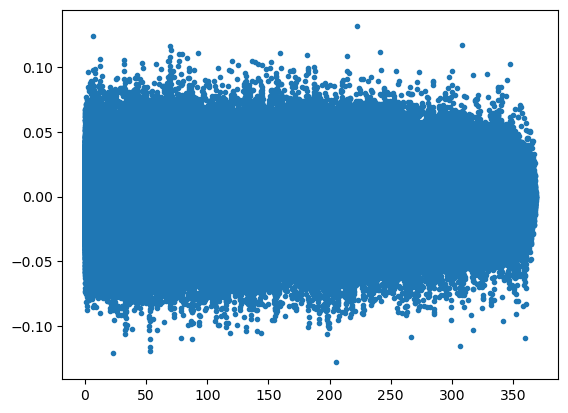

In [17]:
plt.scatter(t_kl, cov, marker='.')
plt.show()

In [16]:
len(t_kl), len(cov)

(13586596, 13586596)

In [19]:
3686*3686

13586596